In [3]:
import pandas as pd
import numpy as np

# Create dataset
data = {
    "Student_ID": [1,2,3,4,5,6,7,8,9,10],
    "Name": ["A","B","C",np.nan,"E",np.nan,"G","H","I","J"],
    "Gender": ["M","F","F","M","F",np.nan,"F","M","F","M"],
    "Math_Score": [85, 90, np.nan, 40, 95, 200, 88, 76, np.nan, 65],
    "Science_Score": [78, 85, 82, np.nan, 91, 89, 300, 72, 80, 60],
    "Attendance (%)": [95, 88, 92, 85, np.nan, 110, 87, 90, 93, 85],
    "Study_Hours": [2, 3, 4, 1, 5, 10, 3, 2, 4, np.nan]
}

df = pd.DataFrame(data)
df

,Student_ID,Name,Gender,Math_Score,Science_Score,Attendance (%),Study_Hours
0,1,A,M,85.0,78.0,95.0,2.0
1,2,B,F,90.0,85.0,88.0,3.0
2,3,C,F,NaN,82.0,92.0,4.0
3,4,NaN,M,40.0,NaN,85.0,1.0
4,5,E,F,95.0,91.0,NaN,5.0
5,6,NaN,NaN,200.0,89.0,110.0,10.0
6,7,G,F,88.0,300.0,87.0,3.0
7,8,H,M,76.0,72.0,90.0,2.0
8,9,I,F,NaN,80.0,93.0,4.0
9,10,J,M,65.0,60.0,85.0,NaN


In [4]:
df.isnull().sum()

Student_ID        0
Name              2
Gender            1
Math_Score        2
Science_Score     1
Attendance (%)    1
Study_Hours       1
dtype: int64

In [5]:
Q1 = df["Math_Score"].quantile(0.25)
Q3 = df["Math_Score"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Math_Score'] = df['Math_Score'].clip(lower,upper)
outliers  = df['Math_Score'].clip(lower,upper)
outliers



0     85.00
1     90.00
2       NaN
3     46.25
4     95.00
5    118.25
6     88.00
7     76.00
8       NaN
9     65.00
Name: Math_Score, dtype: float64

In [7]:
q1 =df["Math_Score"].quantile(0.25)
q3 =df["Math_Score"].quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr

df["Math_Score"].clip(lower, upper)

0     85.00
1     90.00
2       NaN
3     46.25
4     95.00
5    118.25
6     88.00
7     76.00
8       NaN
9     65.00
Name: Math_Score, dtype: float64

In [8]:
df["Math_Score"] = df["Math_Score"].fillna(df["Math_Score"].mean())
df["Science_Score"] = df["Science_Score"].fillna(df["Science_Score"].mean())
df["Attendance (%)"] = df["Attendance (%)"].fillna(df["Attendance (%)"].mean())
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mean())
df["Name"] = df["Name"].fillna(df["Name"].mode()[0])
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])


In [71]:
df.isnull().sum()

Student_ID        0
Name              0
Gender            0
Math_Score        0
Science_Score     0
Attendance (%)    0
Study_Hours       0
dtype: int64

In [72]:
# Attendance should be between 0 and 100
df["Attendance (%)"] = df["Attendance (%)"].clip(0, 100)

In [73]:
Q1 = df["Math_Score"].quantile(0.25)
Q3 = df["Math_Score"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Math_Score'] = df['Math_Score'].clip(lower,upper)
outliers  = df['Math_Score'].clip(lower,upper)
outliers
# lower
# upper

0     85.000000
1     90.000000
2     82.937500
3     60.085938
4     95.000000
5    107.148438
6     88.000000
7     76.000000
8     82.937500
9     65.000000
Name: Math_Score, dtype: float64

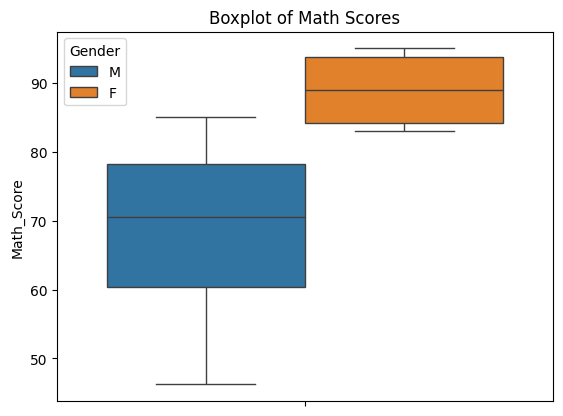

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing Math Scores from your dataframe
sns.boxplot(y=df['Math_Score'], hue=df["Gender"] , showfliers = False)
plt.title('Boxplot of Math Scores')
plt.show()

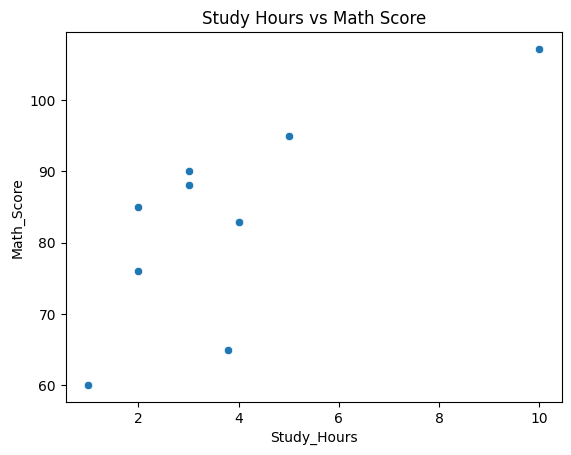

In [75]:
sns.scatterplot(x='Study_Hours', y='Math_Score', data=df)
plt.title('Study Hours vs Math Score')
plt.show()

In [34]:
df["Math_Score"] = np.where(df["Math_Score"] > upper, upper, df["Math_Score"])
df["Math_Score"] = np.where(df["Math_Score"] < lower, lower, df["Math_Score"])

In [35]:
Q1 = df["Math_Score"].quantile(0.25)
Q3 = df["Math_Score"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Math_Score"] < lower) | (df["Math_Score"] > upper)]
outliers

,Student_ID,Name,Gender,Math_Score,Science_Score,Attendance (%),Study_Hours,Study_Hours_log,Math_Score_norm


In [31]:
df["Study_Hours_log"] = np.log(df["Study_Hours"])

In [78]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
# Pass the actual column from the dataframe, reshaped to 2D
df['Math_Norm'] = scalar.fit_transform(df[['Math_Score']])

In [79]:
df.head(10)

,Student_ID,Name,Gender,Math_Score,Science_Score,Attendance (%),Study_Hours,Math_Norm
0,1,A,M,85.000000,78.000000,95.000000,2.000000,0.529382
1,2,B,F,90.000000,85.000000,88.000000,3.000000,0.635624
2,3,C,F,82.937500,82.000000,92.000000,4.000000,0.485558
3,4,A,M,60.085938,104.111111,85.000000,1.000000,0.000000
4,5,E,F,95.000000,91.000000,91.666667,5.000000,0.741866
5,6,A,F,107.148438,89.000000,100.000000,10.000000,1.000000
6,7,G,F,88.000000,300.000000,87.000000,3.000000,0.593127
7,8,H,M,76.000000,72.000000,90.000000,2.000000,0.338147
8,9,I,F,82.937500,80.000000,93.000000,4.000000,0.485558
9,10,J,M,65.000000,60.000000,85.000000,3.777778,0.104416
